#  Modèles ARCH et GARCH avec la méthode de moments généralisés

* [pip install cvxopt]

In [277]:
#import cvxopt
from functools import partial
import math
import numpy as np
import scipy
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera

import matplotlib.pyplot as plt

#np.random.seed(777) #jackpot

## Simuler un GARCH(1,1)

La dynamique de la série temporelle est donnée par :

$$
x_t = \sigma_t \,\varepsilon_t
\quad \text{avec } \varepsilon_t \sim \mathcal{N}(0,1),
$$

$$
\sigma_t^2 = a_0 + b_1\,\sigma_{t-1}^2 + a_1\,x_{t-1}^2,
$$

$$
\sigma_0 = \sqrt{\frac{a_0}{1-a_1-b_1}}.
$$

Nos paramètres sont $a_0=1$, $a_1=0.1$ et $b_1=0.8$.

Nous laisserons tomber les premiers $10\%$ des valeurs simulées (burn-in).


In [278]:
# Define parameters
a0 = 1.0
a1 = 0.1
b1 = 0.8
sigma1 = np.sqrt(a0 / (1 - a1 - b1)) #sigma1=sigma_0

print(list(range(1,4)))

[1, 2, 3]


In [279]:
def simulate_GARCH(T, a0, a1, b1, sigma1):
    
    # Initialize our values
    X = np.ndarray(T)
    sigma = np.ndarray(T)
    sigma[0] = sigma1
   
    for t in range(1, T):
     X[t-1] = sigma[t-1] * np.random.normal()
     sigma[t] = math.sqrt(a0 + a1 * (X[t-1]**2) + b1 * (sigma[t-1]**2))

    X[T-1] = sigma[T-1] * np.random.normal()
     
    
    return X, sigma

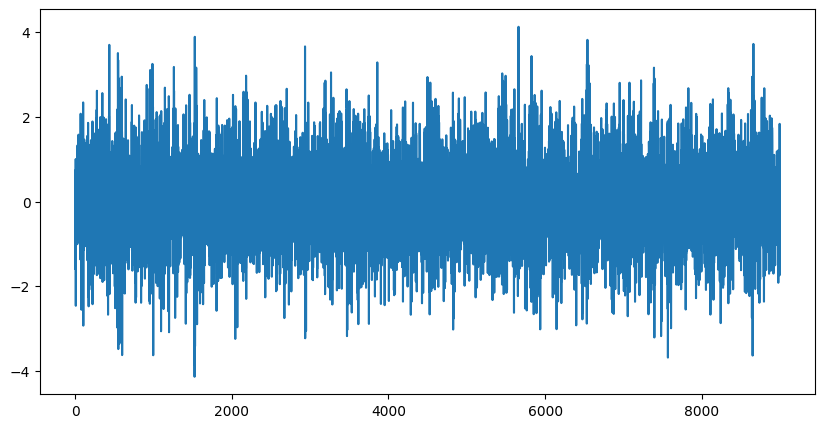

In [280]:
# T=10000, faire "burn in de 1000", normaliser X puis faire un plot
X, _ = simulate_GARCH(10000, a0, a1, b1, sigma1)
# Compléter 
X= X[1000:] # burn in

#scale
X=X/np.std(X)


plt.figure(figsize=(10,5))
plt.plot(X)

Nous allons maintenant comparer les queues de distribution du processus GARCH (1, 1) avec celles d'une loi normale. Nous nous attendons à voir des queues plus grosses, car le processus GARCH (1, 1) aura plus souvent des valeurs extrêmes.

In [281]:
# calculer P(X>k) et P(G>k) pour k=1,2,3,4 
np.random.seed(777)
def compare_tails_to_normal(X):
    
    A = np.zeros((2,4))
    for k in range(4):
        # X tails
        A[0, k] = np.sum(X > (k+1)) / float(len(X))
        # Normal tails
        
        #G tails use stats.norm.cdf
        A[1, k] = 1 - stats.norm.cdf(k+1)
       
        
    return A

compare_tails_to_normal(X)

array([[1.52333333e-01, 2.53333333e-02, 2.33333333e-03, 1.11111111e-04],
       [1.58655254e-01, 2.27501319e-02, 1.34989803e-03, 3.16712418e-05]])

Les queues de distribution du processus GARCH(1, 1) sont plus épaisses.

(array([0.00131494, 0.        , 0.        , 0.00065747, 0.00065747,
        0.00131494, 0.00657471, 0.00525977, 0.00723218, 0.01512183,
        0.02695631, 0.03353102, 0.04405055, 0.06048733, 0.08284134,
        0.11571489, 0.16765509, 0.1742298 , 0.23603207, 0.25970102,
        0.3030941 , 0.35766419, 0.39316762, 0.37541591, 0.40237222,
        0.38067568, 0.35766419, 0.37738832, 0.31098376, 0.28205503,
        0.25246884, 0.21236311, 0.1788321 , 0.14069878, 0.10059305,
        0.07363675, 0.06180227, 0.03879079, 0.03090113, 0.01380689,
        0.01249195, 0.00788965, 0.00394483, 0.00525977, 0.00262988,
        0.00065747, 0.        , 0.        , 0.        , 0.00065747]),
 array([-4.17917942, -4.01018167, -3.84118392, -3.67218617, -3.50318842,
        -3.33419066, -3.16519291, -2.99619516, -2.82719741, -2.65819966,
        -2.4892019 , -2.32020415, -2.1512064 , -1.98220865, -1.8132109 ,
        -1.64421314, -1.47521539, -1.30621764, -1.13721989, -0.96822214,
        -0.79922439, -0.63

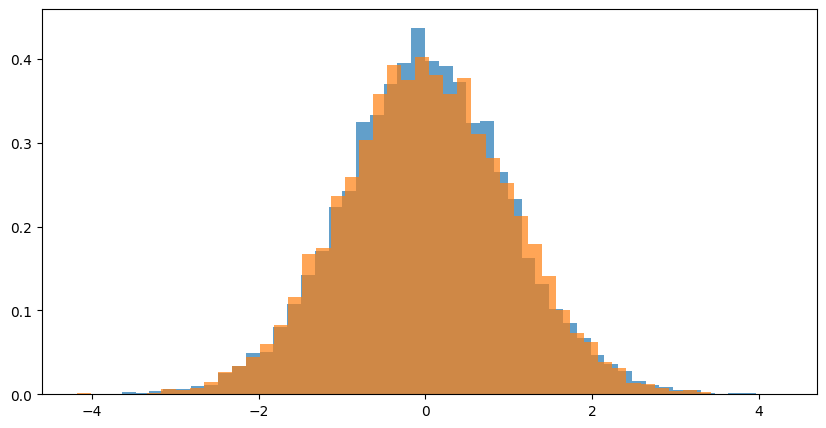

In [282]:
plt.figure(figsize=(10,5))
# Faire des histplots de X et de G

X2 = np.random.normal(size=len(X))
plt.hist(X,density=True,bins=50,alpha=0.7)

plt.hist(X2,density=True,bins=50,alpha=0.7)

Text(0, 0.5, 'sigma')

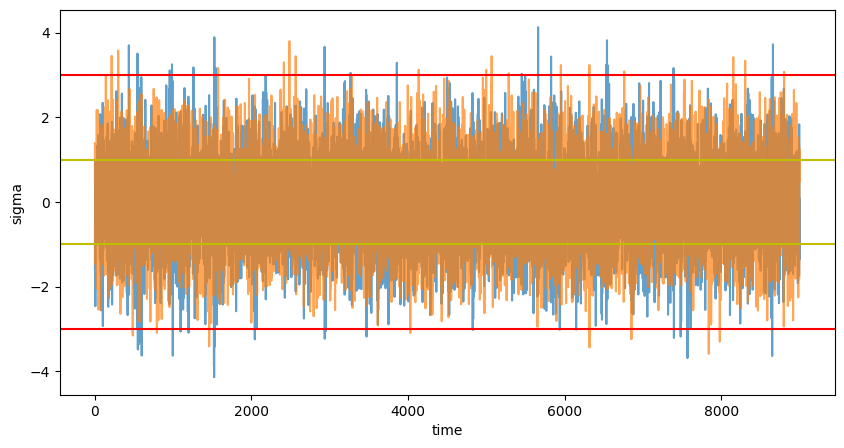

In [283]:
G = np.random.normal(size=len(X))
both = np.matrix([X, G])

# Faire un plot de X et de G et les droite +- ecart type de X et +-3* ecart type de G et conclure
plt.figure(figsize=(10,5))
# Compléter 
plt.plot(X,alpha=0.7)
plt.plot(G,alpha=0.7)
plt.axhline(y = np.std(X), color = 'y', linestyle = '-')
plt.axhline(y = -np.std(X), color = 'y', linestyle = '-')
plt.axhline(y = 3*np.std(G), color = 'r', linestyle = '-')
plt.axhline(y = -3*np.std(G), color = 'r', linestyle = '-')


plt.xlabel('time')
plt.ylabel('sigma')

Nous examinons ici le processus GARCH en bleu et le processus normal en orangé.
Nous pouvons constater que le processus GARCH bleu a tendance à franchir la barre (3 $\times$ écart type ) beaucoup plus souvent que la loi normale.

## Tester un comportement ARCH

La première étape consiste à tester les conditions ARCH. Pour ce faire, nous effectuons une régression sur $ x_t $ correspondant au modèle suivant.

$$x_t^2 = a_0 + a_1 x_{t-1}^2 + \dots + a_p x_{t-p}^2$$

On utilisera OLS pour estimer  $\hat\theta = (\hat a_0, \hat a_1, \dots, \hat a_p)$ et la matrice de covariance $\hat\Omega$. On peut après calculer le test statistique 

$$F = \hat\theta \hat\Omega^{-1} \hat\theta'$$

Si les données $X$ suivent un modèle ARCH alors forcément F suit une loi de Chi2 avec $p$ degrés de libertés.

On rejettera si $F$ est plus grand que la valeur correspendant à 95% de confiance dans ${\chi}^2_p$ distribution. On fixe $p=20$.

On utilsera OLS de statsmodel : https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html

In [284]:
# on part de données synthétiques (mais on pourrait partir de log return SPY)

X, _ = simulate_GARCH(1100, a0, a1, b1, sigma1)
X = X[100:] # Drop burn in

p = 20

# truncate the first 20 so we have a lag of p's

Y2 = (X**2)[p:]

n=1000-p
X2 = np.ndarray((n, p))
for i in range(p, 1000):
    X2[i - p, :] = np.asarray((X**2)[i-p:i])[::-1] # copie backward

#pour i=p on a X2[0, :] = np.asarray((X**2)[0:p])[::-1]
#pour i=p on a X2[1, :] = np.asarray((X**2)[1:p+1])[::-1]
#...
#pour i=999 on a X2[979, :] = np.asarray((X**2)[979: 989])[::-1]

# Y2=theta.X2  modèle arch

#compléter  use sm.OLS 
model = sm.OLS(Y2, X2)
results = model.fit()
# model=

theta = np.matrix(results.params)

Omega = np.matrix(results.cov_HC0)

#cov_HCO 


# F désigne la statistique use np.asscalar

F = (theta*np.linalg.inv(Omega)*theta.T).item()

print('F = ' + str(F)) 

# p-value
chi2dist=scipy.stats.chi2(p)
pvalue =  1- chi2dist.cdf(F)  # 1- fonction de répartition d'une chi2(p)
print('P( Xi2(p) >F ) =' + str("%.5f" % pvalue)) # P( Xi2(p) >F ) <-- p-value

# p-value < alpha=0.05 donc on rejette H0 (i.e. X ne suit pas un modèle ARCH)

# Faites le test avec les valeurs critiques de la chi2 ? 

F = 468.7660273201326
P( Xi2(p) >F ) =0.00000


## Calibrer un modèle GARCH(1, 1) avec EMV
Une fois que nous avons décidé que les données pourraient avoir un modèle GARCH (1, 1) sous-jacent, nous aimerions calibrer le modèle GARCH (1, 1) aux données en estimant ses paramètres.

Pour ce faire, nous avons besoin de la fonction log-vraisemblance

$$\mathcal{L}(\theta) = \sum_{t=1}^T - \ln \sqrt{2\pi} - \frac{x_t^2}{2\sigma_t^2} - \frac{1}{2}\ln(\sigma_t^2)$$


Pour évaluer cette fonction, nous avons besoin de $ x_t $ et $ \sigma_t $ pour $ 1 \leq t \leq T $. Nous avons $ x_t $, mais nous devons calculer $ \sigma_t $. Pour faire cela, nous devons trouver une valeur pour $ \sigma_1 $. Notre hypothèse sera $ \sigma_1^2 = \hat E [x_t^2] $. Une fois que nous avons notre condition initiale, nous calculons le reste des $ \sigma $ en utilisant l'équation


$$\sigma_t^2 = a_0 + a_1 x_{t-1}^2 + b_1\sigma_{t-1}^2$$

In [285]:
np.random.seed(777)
# Création des données synthétiques qui pourraient être remplacées par log return SPY ou cac40
X, _ = simulate_GARCH(100000, a0, a1, b1, sigma1)
X = X[1000:] # burn in

In [300]:

def compute_squared_sigmas(X, initial_sigma, theta):
    
    a0 = theta[0]
    a1 = theta[1]
    b1 = theta[2]
    
    T = len(X)
    sigma2 = np.ndarray(T)
    
    sigma2[0] = initial_sigma ** 2
    
    for t in range(1, T):
        sigma2[t] = a0 + a1 * (X[t-1] ** 2) + b1 * sigma2[t-1]
        
    
    return sigma2

Regardons les sigmas que nous venons de simuler.

Text(0, 0.5, 'Sigma2')

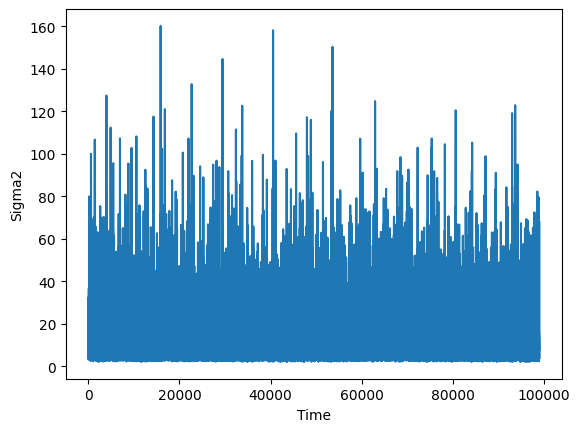

In [301]:
plt.plot(range(len(X)), compute_squared_sigmas(X, np.sqrt(np.mean(X**2)), (1, 0.5, 0.5))) # initial guess (1, 0.5, 0.5)
plt.xlabel('Time')
plt.ylabel('Sigma2')

Maintenant que nous pouvons calculer les $ \sigma_t $, nous allons définir la fonction de vraisemblance. Cette fonction prendra en entrée nos observations $ x $ et $ \theta $ et retournera $ - \mathcal {L} (\theta) $.

Notez que nous re-calculons constamment les $ \sigma_t $ dans cette fonction.

In [302]:
def negative_log_likelihood(X, theta):
    
    # il faut optimiser theta
    
    T = len(X)
    
    # Estimate initial sigma squared
    initial_sigma=np.sqrt(np.mean(X**2))
    
    
    # Generate the squared sigma values
    sigma2=compute_squared_sigmas(X, initial_sigma, theta) 
    
    return - sum(-0.5 * (np.log(sigma2[t]) + X[t]**2 / sigma2[t]) for t in range(T))

Maintenant on optimise numériquement 
$$\hat\theta = \arg \max_{(a_0, a_1, b_1)}\mathcal{L}(\theta) = \arg \min_{(a_0, a_1, b_1)}-\mathcal{L}(\theta)$$

Sous les contraintes

$$a_0 \geq 0, a_1 \geq 0, b_1 \geq 0, a_1+b_1 < 1$$

Voir : 
https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html


In [303]:
np.random.seed(777)

# Make our objective function by plugging X into our log likelihood function
objective = partial(negative_log_likelihood, X)

# Define the constraints for our minimizer
#def constraint0(theta):
#    return  ???

def constraint1(theta):
    return np.array([1 - (theta[1] + theta[2])])  # a1 + b1 < 1

def constraint2(theta):
    return theta[1]  # a1 > 0

def constraint3(theta):
    return theta[2]  # b1 > 0

def constraint4(theta):
    return theta[0]  # a0 > 0

cons = ({'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4})

# Actually do the minimization scipy.optimize.minimize
result = scipy.optimize.minimize(objective, x0=(0.1, 0.5, 0.5), method='SLSQP', constraints=cons)
theta_mle = result.x
print('theta MLE: ' + str(theta_mle))

C:\Users\lione\AppData\Local\Temp\ipykernel_5048\2794730685.py:14: RuntimeWarning: invalid value encountered in log
  return - sum(-0.5 * (np.log(sigma2[t]) + X[t]**2 / sigma2[t]) for t in range(T))


theta MLE: [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]


Maintenant, nous voudrions un moyen de vérifier notre estimation. Nous allons regarder deux choses:

1. Quelle est la taille des queues de distribution ?
2. Faire le test de normalité de  Jarque-Bera.


In [304]:

def check_theta_estimate(X, theta_estimate):
    initial_sigma = np.sqrt(np.mean(X**2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta_estimate))
    epsilon = X / sigma
    print('Tails table')
    print(compare_tails_to_normal(epsilon / np.std(epsilon)))
    print('')
    
    
    _, pvalue, _, _ = jarque_bera(epsilon)
    print('Jarque-Bera probability normal: ' + str(pvalue))
    
check_theta_estimate(X, theta_mle)

Tails table
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.58655254e-01 2.27501319e-02 1.34989803e-03 3.16712418e-05]]

Jarque-Bera probability normal: nan


C:\Users\lione\AppData\Local\Temp\ipykernel_5048\3012303717.py:3: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta_estimate))


## Prédire le future
Maintenant que nous avons calibré le modèle à nos observations, nous aimerions pouvoir prédire à quoi ressemblera la volatilité future. Pour ce faire, nous pouvons simplement simuler plus de valeurs en utilisant notre dynamique GARCH originale et les paramètres estimés.


In [ ]:
# compléter 
sigma_hats = np.sqrt(compute_squared_sigmas(X, np.sqrt(np.mean(X**2)), theta_mle))

initial_sigma = sigma_hats[-1]
initial_sigma

C:\Users\lione\AppData\Local\Temp\ipykernel_5048\674691437.py:2: RuntimeWarning: invalid value encountered in sqrt
  sigma_hats = np.sqrt(compute_squared_sigmas(X, np.sqrt(np.mean(X**2)), theta_mle))


np.float64(nan)

Simuler des valeurs futures

In [309]:
a0_estimate =  theta_mle[0]
a1_estimate = theta_mle[1]
b1_estimate =theta_mle[2]

X_forecast, sigma_forecast = simulate_GARCH(100, a0_estimate, a1_estimate, b1_estimate, initial_sigma)

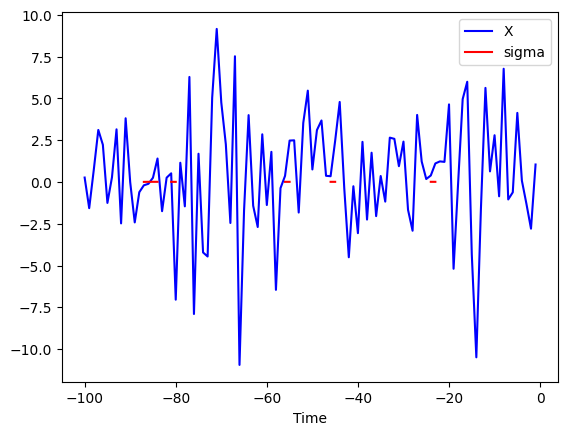

In [ ]:

plt.plot(range(-100, 0), X[-100:], 'b-')
plt.plot(range(-100, 0), sigma_hats[-100:], 'r-')
plt.plot(range(0, 100), X_forecast, 'b--')
plt.plot(range(0, 100), sigma_forecast, 'r--')
plt.xlabel('Time')
plt.legend(['X', 'sigma'])

En pratique, on voudrait probablement générer des milliers de scénarios futurs, puis examiner la plage potentielle de sorties (risque de hausse de volatilité)


ValueError: x and y must have same first dimension, but have shapes (100,) and (1,)

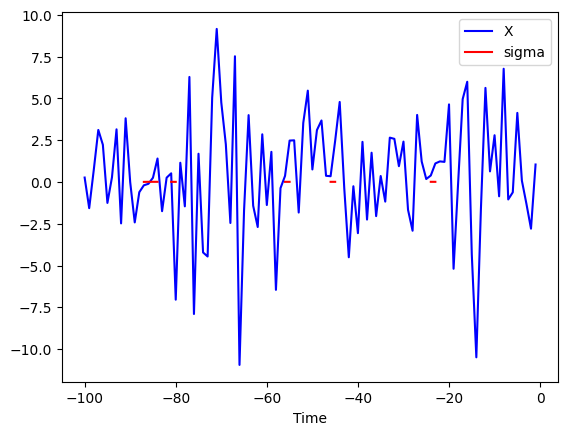

In [313]:
M=100 # taille des simulations des prédictions
N = 100 # nombre de prochaines dates à prédire

plt.plot(range(-N, 0), X[-N:], 'b-')
plt.plot(range(-N, 0), sigma_hats[-N:], 'r-')
plt.xlabel('Time')
plt.legend(['X', 'sigma'])


max_X = [-np.inf]
min_X = [np.inf]
for i in range(M):
    X_forecast, sigma_forecast = simulate_GARCH(N, a0_estimate, a1_estimate, b1_estimate, initial_sigma)
    if max(X_forecast) > max(max_X):
        max_X = X_forecast
    elif min(X_forecast) < min(max_X):
        min_X = X_forecast
    plt.plot(range(0, N), X_forecast, 'b--', alpha=0.05)
    plt.plot(range(0, N), sigma_forecast, 'r--', alpha=0.05)

# Draw the most extreme X values specially
plt.plot(range(0, N), max_X, 'g--', alpha=1.0)
plt.plot(range(0, N), min_X, 'g--', alpha=1.0);

## GMM pour estimer les paramètres du modèle GARCH(1, 1) 

Réference méthode GMM https://swopec.hhs.se/hastef/papers/hastef0434.pdf

Pour cela, on a besoin de 

1. Le résidu $\hat\epsilon_t = x_t / \hat\sigma_t$
2. La variance du résidu $\hat\epsilon_t^2$
3. Le skew  $\mu_3/\hat\sigma_t^3 = (\hat\epsilon_t - E[\hat\epsilon_t])^3 / \hat\sigma_t^3$
4. Le kurtosis  $\mu_4/\hat\sigma_t^4 = (\hat\epsilon_t - E[\hat\epsilon_t])^4 / \hat\sigma_t^4$

In [ ]:
# The n-th standardized moment
# skewness is 3, kurtosis is 4
def standardized_moment(x, mu, sigma, n):
    return ((x - mu) ** n) / (sigma ** n)

MMG se fait en trois étapes:

Commencer par $W$ comme une matrice identité.

1. Estimer $\hat\theta_1$ en minimisant numériquement

$$\min_{\theta \in \Theta} \left(\frac{1}{T} \sum_{t=1}^T g(x_t, \hat\theta)\right)' W \left(\frac{1}{T}\sum_{t=1}^T g(x_t, \hat\theta)\right)$$

2. Recalculer $W$ en se basant sur les  covariances du $\theta$ estimé. 
$$\hat W_{i+1} = \left(\frac{1}{T}\sum_{t=1}^T g(x_t, \hat\theta_i)g(x_t, \hat\theta_i)'\right)^{-1}$$

3. Répéter jusqu'à ce que  $|\hat\theta_{i+1} - \hat\theta_i| < \epsilon$ ou on atteint un seuil fixé.

Initialiser $W$ et $T$ et définir la fonction objectif qu'on doit minimiser.

In [ ]:
def gmm_objective(X, W, theta):
    # Compute the residuals for X and theta
    initial_sigma = np.sqrt(np.mean(X ** 2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))
    e = X / sigma # résidus
    
    # Compute the mean moments errors
    m1 = np.mean(e)
    m2 = np.mean(e**2) - 1
    m3 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 3))
    m4 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 4) - 3)
    
    G = np.matrix([m1, m2, m3, m4]).T
    
    return (G.T * W * G).item()

def gmm_variance(X, theta):
    # Compute the residuals for X and theta    
    initial_sigma = np.sqrt(np.mean(X ** 2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))
    e = X / sigma

    # Compute the squared moments errors
    m1 = np.mean(e)
    m2 = np.mean(e**2) - 1
    m3 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 3))
    m4 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 4) - 3)
    
    # Compute the covariance matrix g * g'
    T = len(X)
    s = np.ndarray((4, 1))
    for t in range(T):
        G = np.matrix([m1, m2, m3, m4]).T
        s = s + G * G.T
    
    return s / T

In [ ]:
# Initialize GMM parameters
W = np.identity(4) # matrice identité 4x4

gmm_iterations = 10 # on pourrait changer cela par un while  |theta_{i+1} -theta_i| <epsilon

# First guess
theta_gmm_estimate = theta_mle

# Perform iterated GMM
for i in range(gmm_iterations):
    # Estimate new theta
    objective = partial(gmm_objective, X, W)
    result = scipy.optimize.minimize(objective, theta_gmm_estimate, constraints=cons)
    theta_gmm_estimate = result.x
    print('Iteration '+str(i)+ ' theta : ' + str(theta_gmm_estimate))
    
check_theta_estimate(X, theta_gmm_estimate)

C:\Users\lione\AppData\Local\Temp\ipykernel_5048\155234857.py:4: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))


Iteration 0 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Iteration 1 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Iteration 2 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Iteration 3 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Iteration 4 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Iteration 5 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Iteration 6 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Iteration 7 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Iteration 8 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Iteration 9 theta : [ 1.23970197e-04 -2.03606125e-04  5.35710135e-06]
Tails table
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.58655254e-01 2.27501319e-02 1.34989803e-03 3.16712418e-05]]

Jarque-Bera probability normal: nan


C:\Users\lione\AppData\Local\Temp\ipykernel_5048\3012303717.py:3: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta_estimate))


## Conclusion : 
on ne peut pas rejeter $H_0$ donc on accepte les résidus sont gaussiens et que le modèle est un GARCH(1,1).

## Prédiction avec GMM

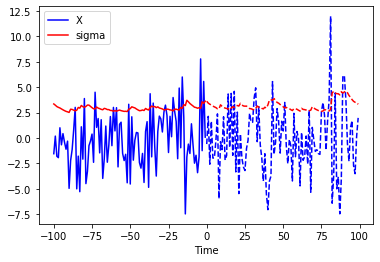

In [ ]:
a0_estimate = theta_gmm_estimate[0]
a1_estimate = theta_gmm_estimate[1]
b1_estimate = theta_gmm_estimate[2]

X_forecast, sigma_forecast = ??


plt.plot(range(-100, 0), X[-100:], 'b-')
plt.plot(range(-100, 0), sigma_hats[-100:], 'r-')
plt.plot(range(0, 100), X_forecast, 'b--')
plt.plot(range(0, 100), sigma_forecast, 'r--')
plt.xlabel('Time')
plt.legend(['X', 'sigma']);